# Notebook 01 — Chuẩn bị & Ghép Dữ liệu (Data Preparation)

**Đề tài 7: Dự báo Năng suất Cây trồng (Crop Yield Prediction)**  
**Nhóm 13 | Dữ liệu: Kaggle Crop Yield Prediction Dataset | 2025–2026**

---

## Mô tả 5 file dữ liệu Kaggle

| File | Mô tả | Kích thước |
|---|---|---|
| `yield.csv` | Năng suất cây trồng theo quốc gia/năm (FAO) | ~56,000 dòng |
| `pesticides.csv` | Lượng thuốc trừ sâu sử dụng (FAO) | ~4,300 dòng |
| `rainfall.csv` | Lượng mưa trung bình hàng năm (World Bank) | ~6,700 dòng |
| `temperature.csv` | Nhiệt độ trung bình năm theo quốc gia | ~71,000 dòng |
| `yield_df.csv` | Dataset đã ghép sẵn (dùng trực tiếp) | ~28,000 dòng |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

RAW  = Path("../data/raw")
PROC = Path("../data/processed"); PROC.mkdir(parents=True, exist_ok=True)
OUT  = Path("../outputs/figures"); OUT.mkdir(parents=True, exist_ok=True)

print("Thư viện đã tải xong.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")

Thư viện đã tải xong.
  pandas  2.3.3
  numpy   2.2.6


## 1. Đọc từng file dữ liệu thô (Raw Data)

In [2]:
# ── Yield (năng suất cây trồng) ──
df_yield = pd.read_csv(RAW / "yield.csv")
print(f"yield.csv:        {df_yield.shape[0]:,} dòng × {df_yield.shape[1]} cột")
print(f"  Năm: {df_yield.Year.min()} – {df_yield.Year.max()}")
print(f"  Quốc gia: {df_yield.Area.nunique()}")
print(f"  Cây trồng: {df_yield.Item.unique().tolist()}")
df_yield.head(3)

yield.csv:        56,717 dòng × 12 cột
  Năm: 1961 – 2016
  Quốc gia: 212
  Cây trồng: ['Maize', 'Potatoes', 'Rice, paddy', 'Wheat', 'Sorghum', 'Soybeans', 'Cassava', 'Yams', 'Sweet potatoes', 'Plantains and others']


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260


In [3]:
# ── Pesticides (thuốc trừ sâu) ──
df_pest = pd.read_csv(RAW / "pesticides.csv")
print(f"pesticides.csv:   {df_pest.shape[0]:,} dòng × {df_pest.shape[1]} cột")
print(f"  Năm: {df_pest.Year.min()} – {df_pest.Year.max()}")
print(f"  Quốc gia: {df_pest.Area.nunique()}")
df_pest.head(3)

pesticides.csv:   4,349 dòng × 7 cột
  Năm: 1990 – 2016
  Quốc gia: 168


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0


In [4]:
# ── Rainfall (lượng mưa) ──
df_rain = pd.read_csv(RAW / "rainfall.csv")
df_rain.columns = df_rain.columns.str.strip()
print(f"rainfall.csv:     {df_rain.shape[0]:,} dòng × {df_rain.shape[1]} cột")
print(f"  Năm: {df_rain.Year.min()} – {df_rain.Year.max()}")
df_rain.head(3)

rainfall.csv:     6,727 dòng × 3 cột
  Năm: 1985 – 2017


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327


In [5]:
# ── Temperature (nhiệt độ) ──
df_temp = pd.read_csv(RAW / "temperature.csv")
print(f"temperature.csv:  {df_temp.shape[0]:,} dòng × {df_temp.shape[1]} cột")
print(f"  Năm: {df_temp.year.min()} – {df_temp.year.max()}")
df_temp.head(3)

temperature.csv:  71,311 dòng × 3 cột


  Năm: 1743 – 2013


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67


In [6]:
# ── yield_df (dataset đã ghép sẵn) ──
df_merged = pd.read_csv(RAW / "yield_df.csv", index_col=0)
print(f"yield_df.csv:     {df_merged.shape[0]:,} dòng × {df_merged.shape[1]} cột")
print(f"  Năm: {df_merged.Year.min()} – {df_merged.Year.max()}")
print(f"  Quốc gia: {df_merged.Area.nunique()}")
print(f"  Cây trồng: {df_merged.Item.unique().tolist()}")
df_merged.head(5)

yield_df.csv:     28,242 dòng × 7 cột
  Năm: 1990 – 2013
  Quốc gia: 101
  Cây trồng: ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat', 'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams']


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 2. Tái tạo quá trình ghép (Data Merging Pipeline)

In [7]:
# Bước 1: Chuẩn hóa yield.csv
yield_clean = df_yield[["Area","Item","Year","Value"]].copy()
yield_clean.columns = ["Area","Item","Year","hg/ha_yield"]

# Bước 2: Chuẩn hóa pesticides.csv
pest_clean = df_pest[["Area","Year","Value"]].copy()
pest_clean.columns = ["Area","Year","pesticides_tonnes"]
# Lấy giá trị mới nhất nếu bị trùng
pest_clean = pest_clean.groupby(["Area","Year"])["pesticides_tonnes"].mean().reset_index()

# Bước 3: Chuẩn hóa rainfall.csv
rain_clean = df_rain[["Area","Year","average_rain_fall_mm_per_year"]].copy()
rain_clean["average_rain_fall_mm_per_year"] = pd.to_numeric(rain_clean["average_rain_fall_mm_per_year"], errors="coerce")

# Bước 4: Chuẩn hóa temperature.csv — chỉ giữ 1990–2013
temp_clean = df_temp[df_temp.year.between(1990, 2013)].copy()
temp_clean.columns = ["Year","Area","avg_temp"]
temp_clean["avg_temp"] = pd.to_numeric(temp_clean["avg_temp"], errors="coerce")
temp_avg = temp_clean.groupby(["Area","Year"])["avg_temp"].mean().reset_index()

print("Thống kê từng bộ sau chuẩn hóa:")
print(f"  yield_clean  : {yield_clean.shape}")
print(f"  pest_clean   : {pest_clean.shape}")
print(f"  rain_clean   : {rain_clean.shape}")
print(f"  temp_avg     : {temp_avg.shape}")

Thống kê từng bộ sau chuẩn hóa:
  yield_clean  : (56717, 4)
  pest_clean   : (4349, 3)
  rain_clean   : (6727, 3)
  temp_avg     : (3288, 3)


In [8]:
# Bước 5: Ghép lần lượt
df_join = yield_clean.merge(pest_clean, on=["Area","Year"], how="left")
df_join = df_join.merge(rain_clean,    on=["Area","Year"], how="left")
df_join = df_join.merge(temp_avg,      on=["Area","Year"], how="left")

# Bước 6: Lọc 1990–2013 (phù hợp với yield_df gốc)
df_join = df_join[df_join.Year.between(1990, 2013)].copy()

print(f"Dataset sau ghép: {df_join.shape}")
print(f"Missing values:\n{df_join.isnull().sum()}")
df_join.head(5)

Dataset sau ghép: (26040, 7)


Missing values:
Area                                 0
Item                                 0
Year                                 0
hg/ha_yield                          0
pesticides_tonnes                 4614
average_rain_fall_mm_per_year     6337
avg_temp                         10243
dtype: int64


,Area,Item,Year,hg/ha_yield,pesticides_tonnes,average_rain_fall_mm_per_year,avg_temp
29,Afghanistan,Maize,1990,17582,NaN,327.0,15.45
30,Afghanistan,Maize,1991,16800,NaN,327.0,14.57
31,Afghanistan,Maize,1992,15000,NaN,327.0,14.35
32,Afghanistan,Maize,1993,16786,NaN,327.0,14.96
33,Afghanistan,Maize,1994,16667,NaN,327.0,14.94


## 3. Sử dụng yield_df.csv (dataset chuẩn)

In [9]:
# Dùng yield_df.csv làm dataset chính (đầy đủ, đã QC)
df = df_merged.copy()
print(f"Dataset chính: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Cột: {list(df.columns)}")
print(f"Missing: {df.isnull().sum().to_dict()}")
print(f"\nYears  : {df.Year.min()} – {df.Year.max()}")
print(f"Areas  : {df.Area.nunique()} quốc gia")
print(f"Items  : {df.Item.nunique()} loại cây: {df.Item.unique().tolist()}")
df.describe().round(2)

Dataset chính: 28,242 dòng × 7 cột
Cột: ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Missing: {'Area': 0, 'Item': 0, 'Year': 0, 'hg/ha_yield': 0, 'average_rain_fall_mm_per_year': 0, 'pesticides_tonnes': 0, 'avg_temp': 0}

Years  : 1990 – 2013
Areas  : 101 quốc gia
Items  : 10 loại cây: ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat', 'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams']


,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.00,28242.00,28242.00,28242.00,28242.00
mean,2001.54,77053.33,1149.06,37076.91,20.54
std,7.05,84956.61,709.81,59958.78,6.31
min,1990.00,50.00,51.00,0.04,1.30
25%,1995.00,19919.25,593.00,1702.00,16.70
50%,2001.00,38295.00,1083.00,17529.44,21.51
75%,2008.00,104676.75,1668.00,48687.88,26.00
max,2013.00,501412.00,3240.00,367778.00,30.65


In [10]:
# Lưu dataset chuẩn
df.to_csv(PROC / "crop_yield_main.csv", index=False)
print(f"Saved: data/processed/crop_yield_main.csv  ({df.shape[0]:,} dòng)")

# Lưu cũng từng file đã chuẩn hóa
pest_clean.to_csv(PROC / "pesticides_clean.csv", index=False)
rain_clean.to_csv(PROC / "rainfall_clean.csv", index=False)
temp_avg.to_csv(PROC / "temperature_clean.csv", index=False)
yield_clean.to_csv(PROC / "yield_clean.csv", index=False)
print("Saved: pesticides_clean, rainfall_clean, temperature_clean, yield_clean")

Saved: data/processed/crop_yield_main.csv  (28,242 dòng)


Saved: pesticides_clean, rainfall_clean, temperature_clean, yield_clean


## 4. Tổng quan trực quan 5 file dữ liệu

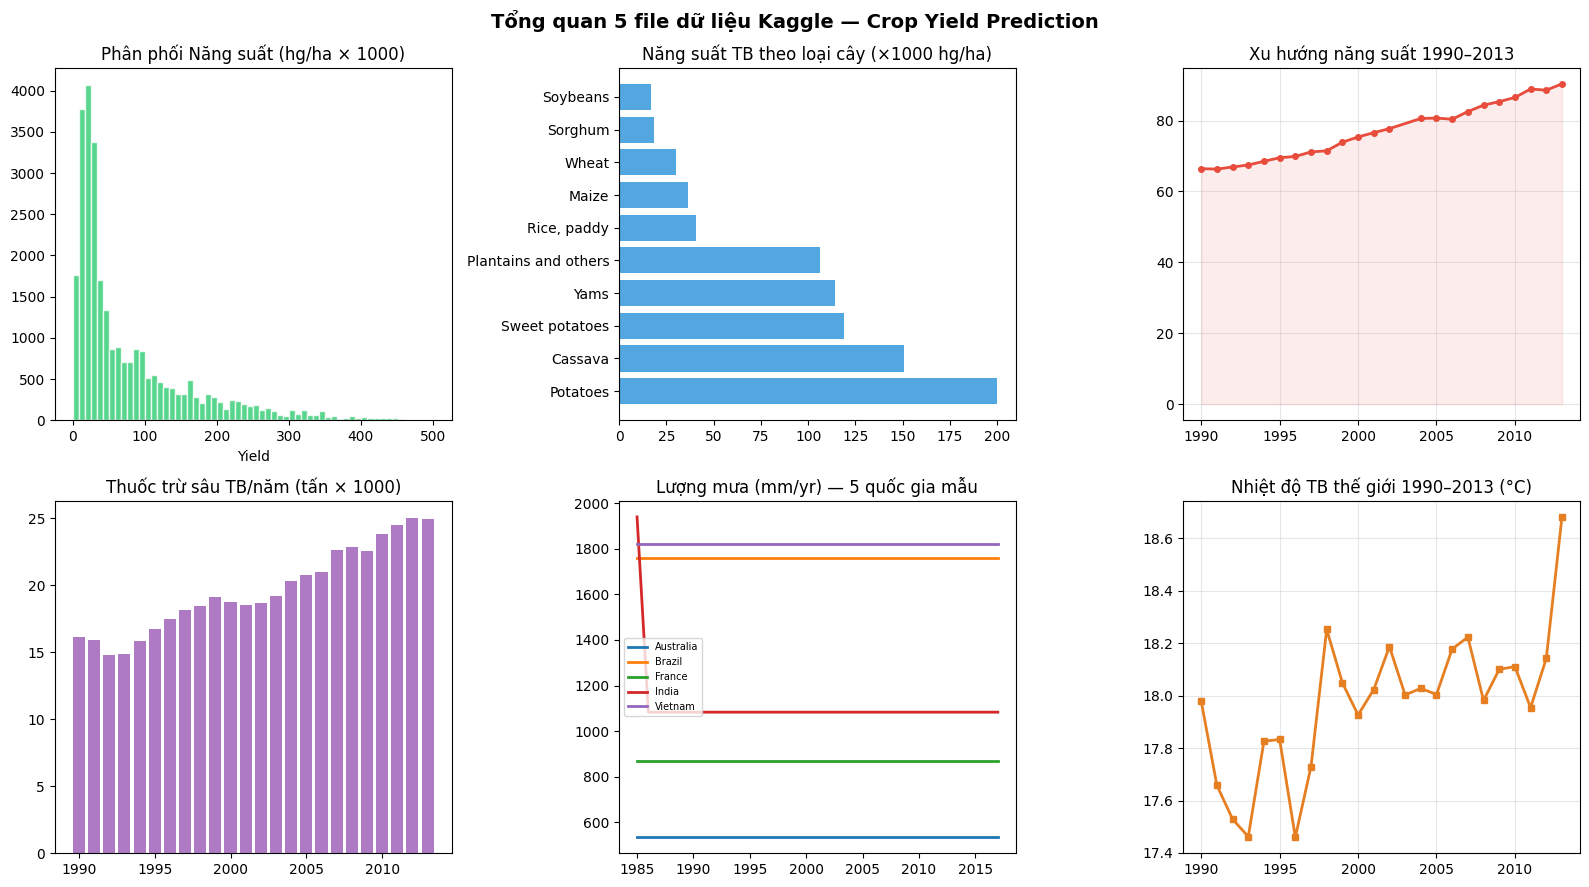

[SAVED] 01_data_overview.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Tổng quan 5 file dữ liệu Kaggle — Crop Yield Prediction", fontsize=14, fontweight="bold")

# 1. Yield distribution
axes[0,0].hist(df["hg/ha_yield"]/1000, bins=60, color="#2ecc71", alpha=0.8, edgecolor="white")
axes[0,0].set_title("Phân phối Năng suất (hg/ha × 1000)"); axes[0,0].set_xlabel("Yield")

# 2. Yield by crop
crop_m = df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending=False)
axes[0,1].barh(crop_m.index, crop_m.values/1000, color="#3498db", alpha=0.85)
axes[0,1].set_title("Năng suất TB theo loại cây (×1000 hg/ha)")

# 3. Year trend
yr = df.groupby("Year")["hg/ha_yield"].mean()
axes[0,2].plot(yr.index, yr.values/1000, "o-", color="#e74c3c", linewidth=2, markersize=4)
axes[0,2].fill_between(yr.index, yr.values/1000, alpha=0.1, color="#e74c3c")
axes[0,2].set_title("Xu hướng năng suất 1990–2013"); axes[0,2].grid(True, alpha=0.3)

# 4. Pesticide trend (top countries)
pest_yr = pest_clean[pest_clean.Year.between(1990,2013)].groupby("Year")["pesticides_tonnes"].mean()
axes[1,0].bar(pest_yr.index, pest_yr.values/1000, color="#9b59b6", alpha=0.8)
axes[1,0].set_title("Thuốc trừ sâu TB/năm (tấn × 1000)")

# 5. Rainfall by country sample
rain_sample = rain_clean[rain_clean.Area.isin(["Vietnam","France","Brazil","India","Australia"])].copy()
rain_sample["average_rain_fall_mm_per_year"] = pd.to_numeric(rain_sample["average_rain_fall_mm_per_year"], errors="coerce")
for area, grp in rain_sample.groupby("Area"):
    axes[1,1].plot(grp.Year, grp.average_rain_fall_mm_per_year, label=area, linewidth=2)
axes[1,1].set_title("Lượng mưa (mm/yr) — 5 quốc gia mẫu"); axes[1,1].legend(fontsize=7)

# 6. Temperature trend
temp_world = df_temp[df_temp.year.between(1990,2013)].copy()
temp_world["avg_temp"] = pd.to_numeric(temp_world["avg_temp"], errors="coerce")
temp_yr = temp_world.groupby("year")["avg_temp"].mean()
axes[1,2].plot(temp_yr.index, temp_yr.values, "s-", color="#e67e22", linewidth=2, markersize=4)
axes[1,2].set_title("Nhiệt độ TB thế giới 1990–2013 (°C)"); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "01_data_overview.png", dpi=100, bbox_inches="tight")
plt.show()
print("[SAVED] 01_data_overview.png")